**Read**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy import stats

df = pd.read_csv('../../data/processed/master_table.csv')

/var/folders/fs/kptg9x9j3sbct4_78wfvvxvh0000gn/T/ipykernel_33557/686404495.py:8: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/processed/master_table.csv')


In [3]:
import pandas as pd

#Eliminar los valores obviamente erroneos -9999
df.replace(-9999, np.nan, inplace=True)

# Arreglar nulos archivo_origen
if 'archivo_origen' in df.columns:
    # Reemplaza los valores nulos en la columna 'archivo_origen'
    df['archivo_origen'] = df['archivo_origen'].fillna('DATOS_HISTORICOS_2024_CONCATENADO.csv')
    print("\nValores nulos en 'archivo_origen' reemplazados con 'DATOS_HISTORICOS_2024_CONCATENADO.csv'.")
    
    # Imprimir los nuevos valores únicos para verificar el cambio
    print("\n=== VALORES ÚNICOS DE 'archivo_origen' DESPUÉS DE RELLENAR ===")
    unique_values = df['archivo_origen'].unique()
    print("Valores distintos en la columna 'archivo_origen':")
    for value in unique_values:
        print(f"- {value}")
else:
    print("\nLa columna 'archivo_origen' no se encuentra en el DataFrame.")
    
print("\n=== INFO GENERAL ===")
print(df.info())
print("\nDimensiones:", df.shape)

# === Valores faltantes ===
print("\n=== VALORES FALTANTES ===")
nulls_by_col = df.isnull().sum()
nulls_percent = (df.isnull().sum() / len(df)) * 100

# Totales
total_nulls = nulls_by_col.sum()
total_cells = df.shape[0] * df.shape[1]
percent_nulls = (total_nulls / total_cells) * 100

print(f"\nTotal de valores nulos en la tabla: {total_nulls:,}")
print(f"Porcentaje de celdas nulas: {percent_nulls:.2f}%")

# También detectar celdas vacías o con solo espacios
empty_cells = (df.applymap(lambda x: str(x).strip() == "" if pd.notnull(x) else False)).sum()
print("\nCeldas vacías (string vacío o solo espacios):")
print(empty_cells[empty_cells > 0])


/var/folders/fs/kptg9x9j3sbct4_78wfvvxvh0000gn/T/ipykernel_33557/343773957.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  empty_cells = (df.applymap(lambda x: str(x).strip() == "" if pd.notnull(x) else False)).sum()



Valores nulos en 'archivo_origen' reemplazados con 'DATOS_HISTORICOS_2024_CONCATENADO.csv'.

=== VALORES ÚNICOS DE 'archivo_origen' DESPUÉS DE RELLENAR ===
Valores distintos en la columna 'archivo_origen':
- DATOS_HISTORICOS_2022_2023_CONCATENADO
- DATOS_HISTORICOS_2023_2024_CONCATENADO.xlsx
- DATOS_HISTORICOS_2024_CONCATENADO.csv

=== INFO GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386494 entries, 0 to 386493
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date_index      386494 non-null  object 
 1   co              364616 non-null  float64
 2   no              368735 non-null  float64
 3   no2             371092 non-null  float64
 4   nox             371546 non-null  float64
 5   o3              369094 non-null  float64
 6   pm10            373557 non-null  float64
 7   pm2.5           290296 non-null  float64
 8   prs             376939 non-null  float64
 9   rainf           380321

In [4]:
print("\n=== VALORES NULOS POR COLUMNA ===")
nulls_table = pd.DataFrame({
    'Valores Nulos': nulls_by_col,
    'Porcentaje (%)': nulls_percent.round(2)
}).sort_values(by='Valores Nulos', ascending=False)

print(nulls_table[nulls_table['Valores Nulos'] > 0])


=== VALORES NULOS POR COLUMNA ===
       Valores Nulos  Porcentaje (%)
pm2.5          96198           24.89
rh             33444            8.65
so2            26938            6.97
co             21878            5.66
no             17759            4.59
o3             17400            4.50
sr             17115            4.43
tout           15652            4.05
no2            15402            3.99
nox            14948            3.87
pm10           12937            3.35
wdr            11352            2.94
wsr            10294            2.66
prs             9555            2.47
rainf           6173            1.60


In [5]:
print("\n=== VALORES POTENCIALMENTE ERRÓNEOS ===")
for col in df.select_dtypes(include=['number']).columns:
    print(f"\nColumna numérica: {col}")
    print("  Valores mínimos y máximos:", df[col].min(), "→", df[col].max())

# Ejemplo: detectar negativos en columnas que no deberían
# (ajusta según tus datos)
numeric_cols = df.select_dtypes(include=['number']).columns
negatives = (df[numeric_cols] < 0).sum()


=== VALORES POTENCIALMENTE ERRÓNEOS ===

Columna numérica: co
  Valores mínimos y máximos: -0.13 → 37.0

Columna numérica: no
  Valores mínimos y máximos: 0.3 → 945.1

Columna numérica: no2
  Valores mínimos y máximos: 0.0 → 167.8

Columna numérica: nox
  Valores mínimos y máximos: 0.5 → 971.8

Columna numérica: o3
  Valores mínimos y máximos: -9.0 → 183.0

Columna numérica: pm10
  Valores mínimos y máximos: 1.0 → 1001.0

Columna numérica: pm2.5
  Valores mínimos y máximos: -1.0 → 999.0

Columna numérica: prs
  Valores mínimos y máximos: 655.4 → 747.6

Columna numérica: rainf
  Valores mínimos y máximos: 0.0 → 83.45

Columna numérica: rh
  Valores mínimos y máximos: 0.0 → 714.2

Columna numérica: so2
  Valores mínimos y máximos: 0.5 → 222.9

Columna numérica: sr
  Valores mínimos y máximos: -0.012 → 7.786

Columna numérica: tout
  Valores mínimos y máximos: -8.75 → 785.0

Columna numérica: wsr
  Valores mínimos y máximos: 0.1 → 215.9

Columna numérica: wdr
  Valores mínimos y máximos:

In [6]:
print("\nValores negativos por columna:")
print(negatives[negatives > 0])


Valores negativos por columna:
co         2
o3         1
pm2.5      1
sr       180
tout     681
dtype: int64


In [7]:
# === 3. Duplicados ===
print("\n=== DUPLICADOS ===")
print("Número de filas duplicadas:", df.duplicated().sum())
print("Ejemplos de duplicados:")
print(df[df.duplicated()].head())


=== DUPLICADOS ===
Número de filas duplicadas: 0
Ejemplos de duplicados:
Empty DataFrame
Columns: [date_index, co, no, no2, nox, o3, pm10, pm2.5, prs, rainf, rh, so2, sr, tout, wsr, wdr, estacion, archivo_origen]
Index: []


In [8]:
# === 4. Errores de escritura (categorías inconsistentes) ===
print("\n=== Valores Categoricos ===")
for col in df.select_dtypes(include=['object']).columns:
    unique_vals = df[col].dropna().unique()
    print(f"\nColumna '{col}' tiene {len(unique_vals)} categorías:")
    print(sorted(unique_vals))


=== Valores Categoricos ===

Columna 'date_index' tiene 26302 categorías:
['2022-01-01 00:00:00', '2022-01-01 01:00:00', '2022-01-01 02:00:00', '2022-01-01 03:00:00', '2022-01-01 04:00:00', '2022-01-01 05:00:00', '2022-01-01 06:00:00', '2022-01-01 07:00:00', '2022-01-01 08:00:00', '2022-01-01 09:00:00', '2022-01-01 10:00:00', '2022-01-01 11:00:00', '2022-01-01 12:00:00', '2022-01-01 13:00:00', '2022-01-01 14:00:00', '2022-01-01 15:00:00', '2022-01-01 16:00:00', '2022-01-01 17:00:00', '2022-01-01 18:00:00', '2022-01-01 19:00:00', '2022-01-01 20:00:00', '2022-01-01 21:00:00', '2022-01-01 22:00:00', '2022-01-01 23:00:00', '2022-01-02 00:00:00', '2022-01-02 01:00:00', '2022-01-02 02:00:00', '2022-01-02 03:00:00', '2022-01-02 04:00:00', '2022-01-02 05:00:00', '2022-01-02 06:00:00', '2022-01-02 07:00:00', '2022-01-02 08:00:00', '2022-01-02 09:00:00', '2022-01-02 10:00:00', '2022-01-02 11:00:00', '2022-01-02 12:00:00', '2022-01-02 13:00:00', '2022-01-02 14:00:00', '2022-01-02 15:00:00', '202

En la columna estacion, encontramos casos de valores que se refieren a lo mismo pero no estan escritos de la misma manera, por ejemplo, NORESTE 3 y NORESTE3

In [9]:
import re

def limpiar_estacion(valor):
    if pd.isna(valor):
        return valor
    # 1. A mayúsculas
    val = str(valor).upper().strip()
    # 2. Quitar espacios redundantes
    val = re.sub(r'\s+', ' ', val)
    # 3. Unificar "X 2" y "X2"
    val = re.sub(r'(\D)\s+(\d+)', r'\1\2', val)  
    return val

df['estacion_limpia'] = df['estacion'].apply(limpiar_estacion)

print(sorted(df['estacion_limpia'].unique()))


['CENTRO', 'NORESTE', 'NORESTE2', 'NORESTE3', 'NOROESTE', 'NOROESTE2', 'NOROESTE3', 'NORTE', 'NORTE2', 'SUR', 'SURESTE', 'SURESTE2', 'SURESTE3', 'SUROESTE', 'SUROESTE2']


Calculando z-scores...

Z-scores calculados para 15 variables
Forma del DataFrame de z-scores: (383691, 15)

Generando boxplots...


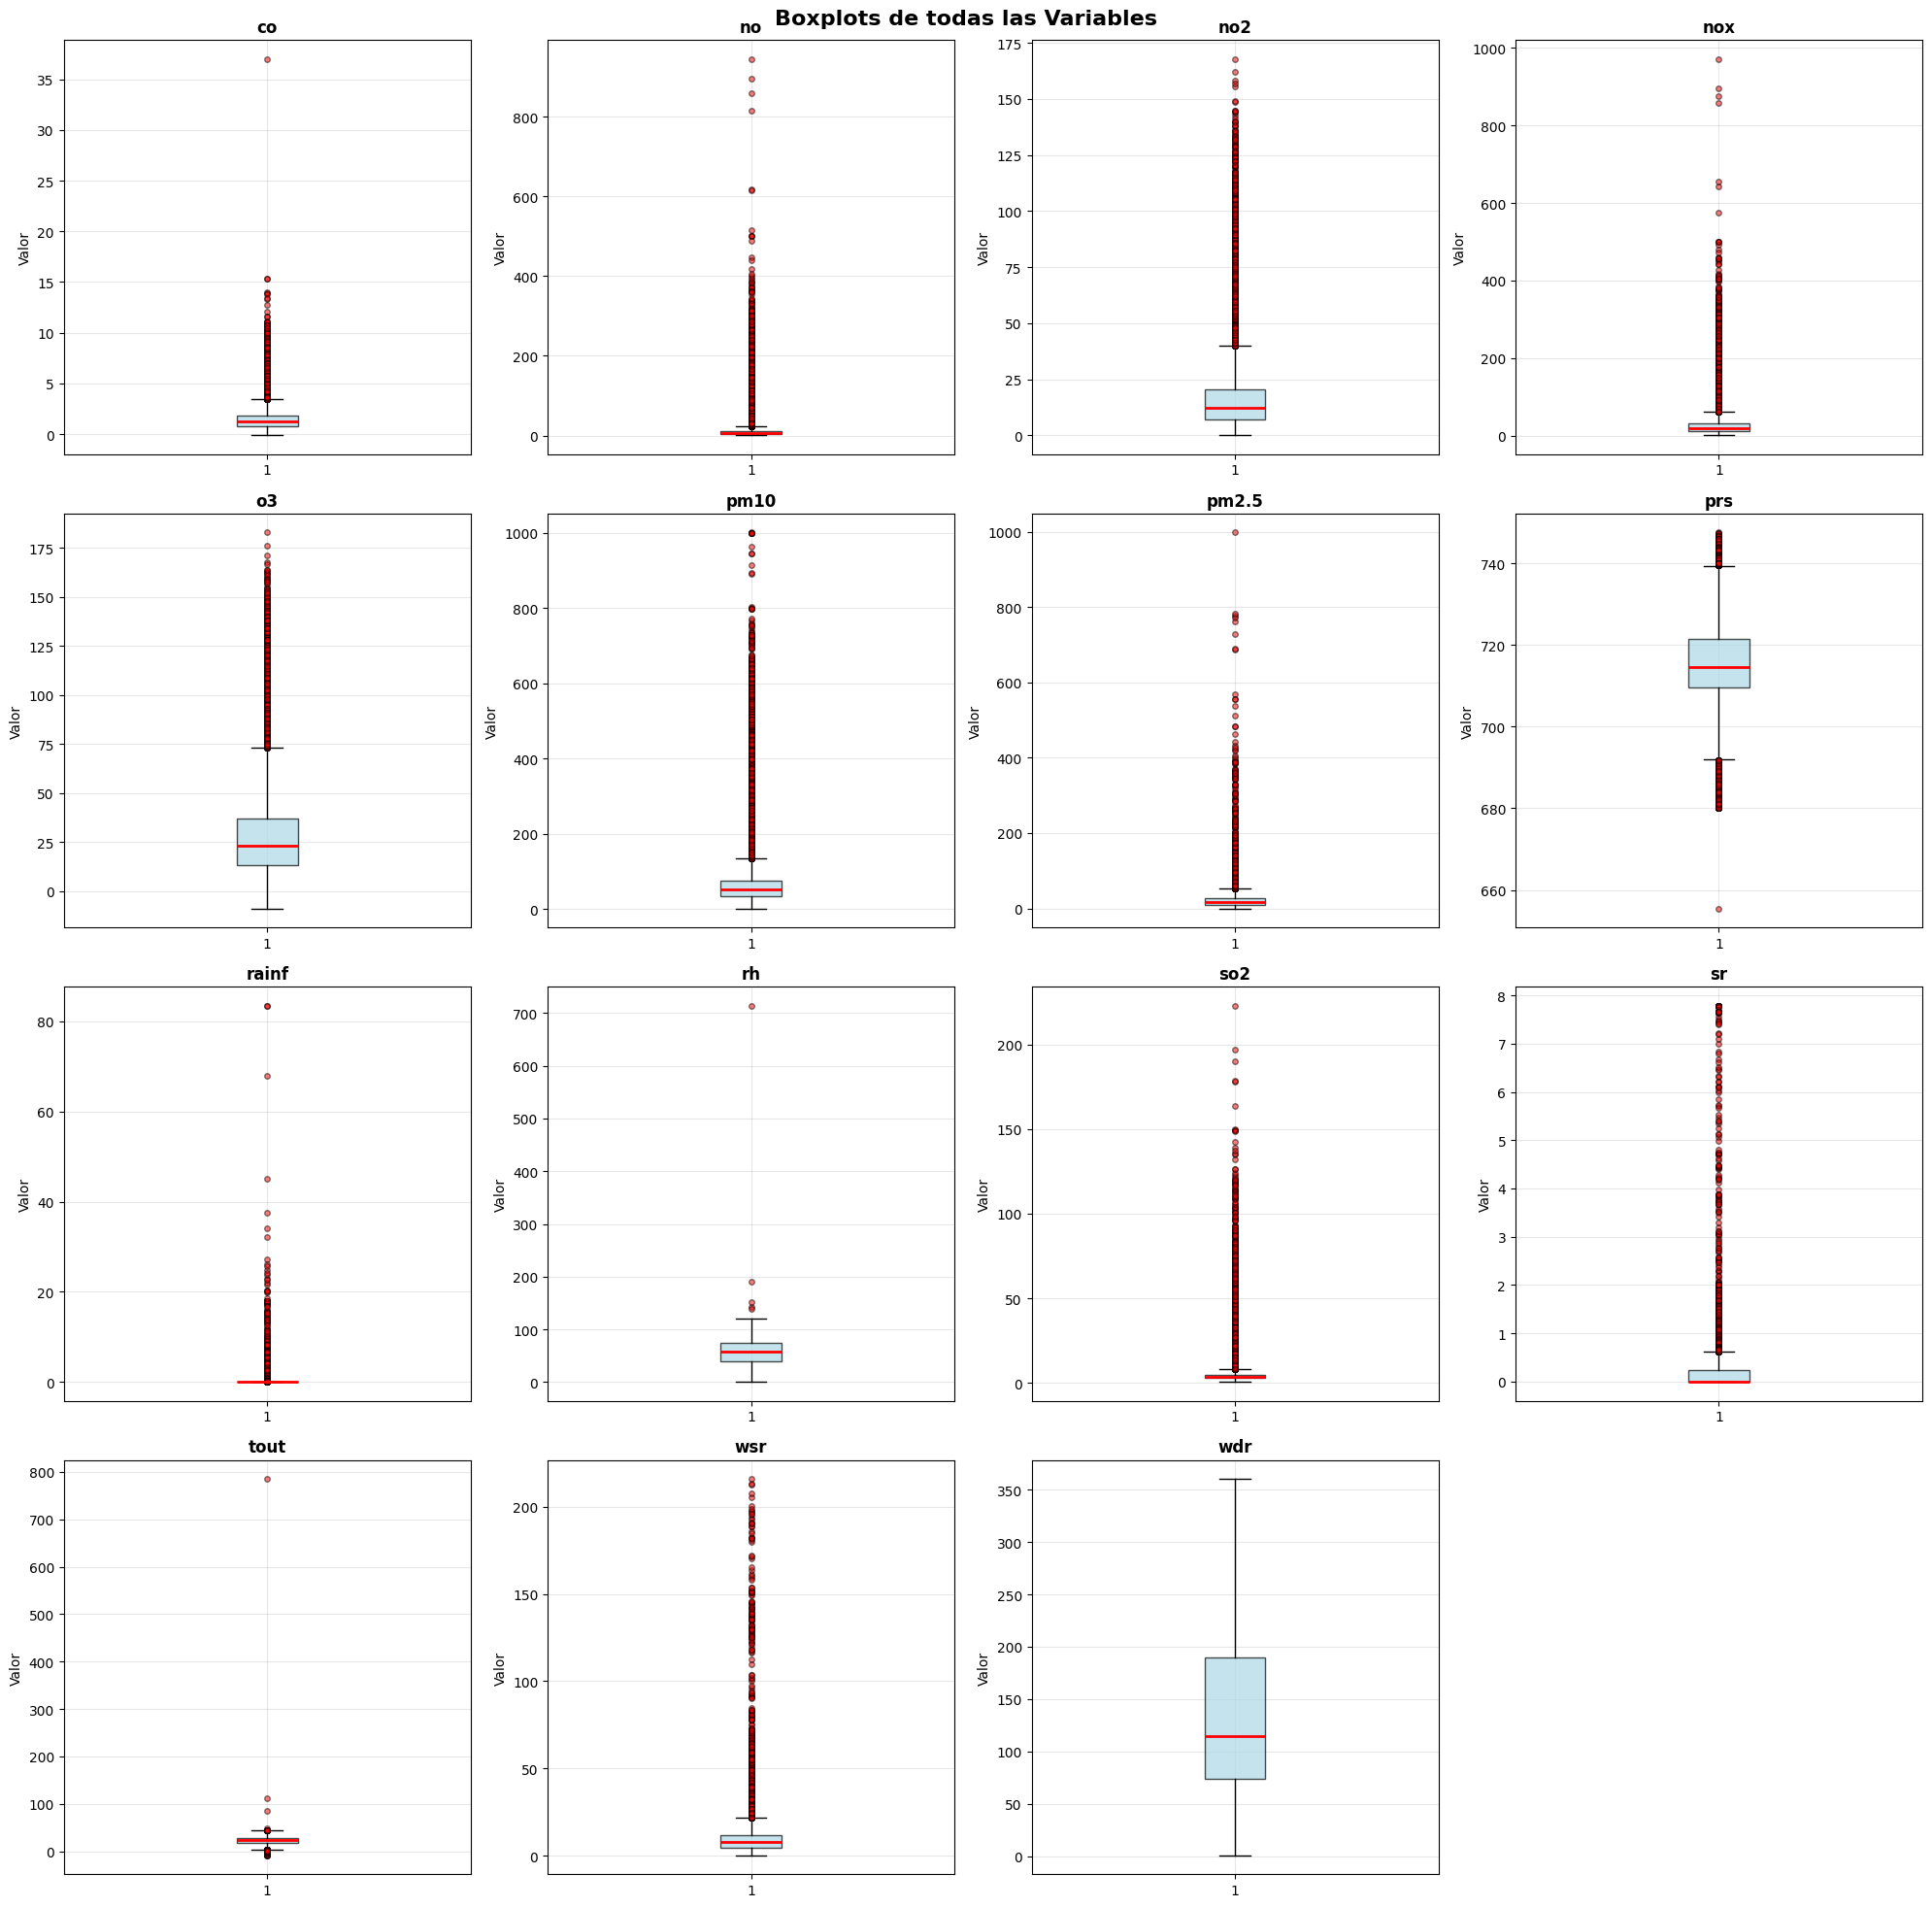


Generando gráficas de z-scores...


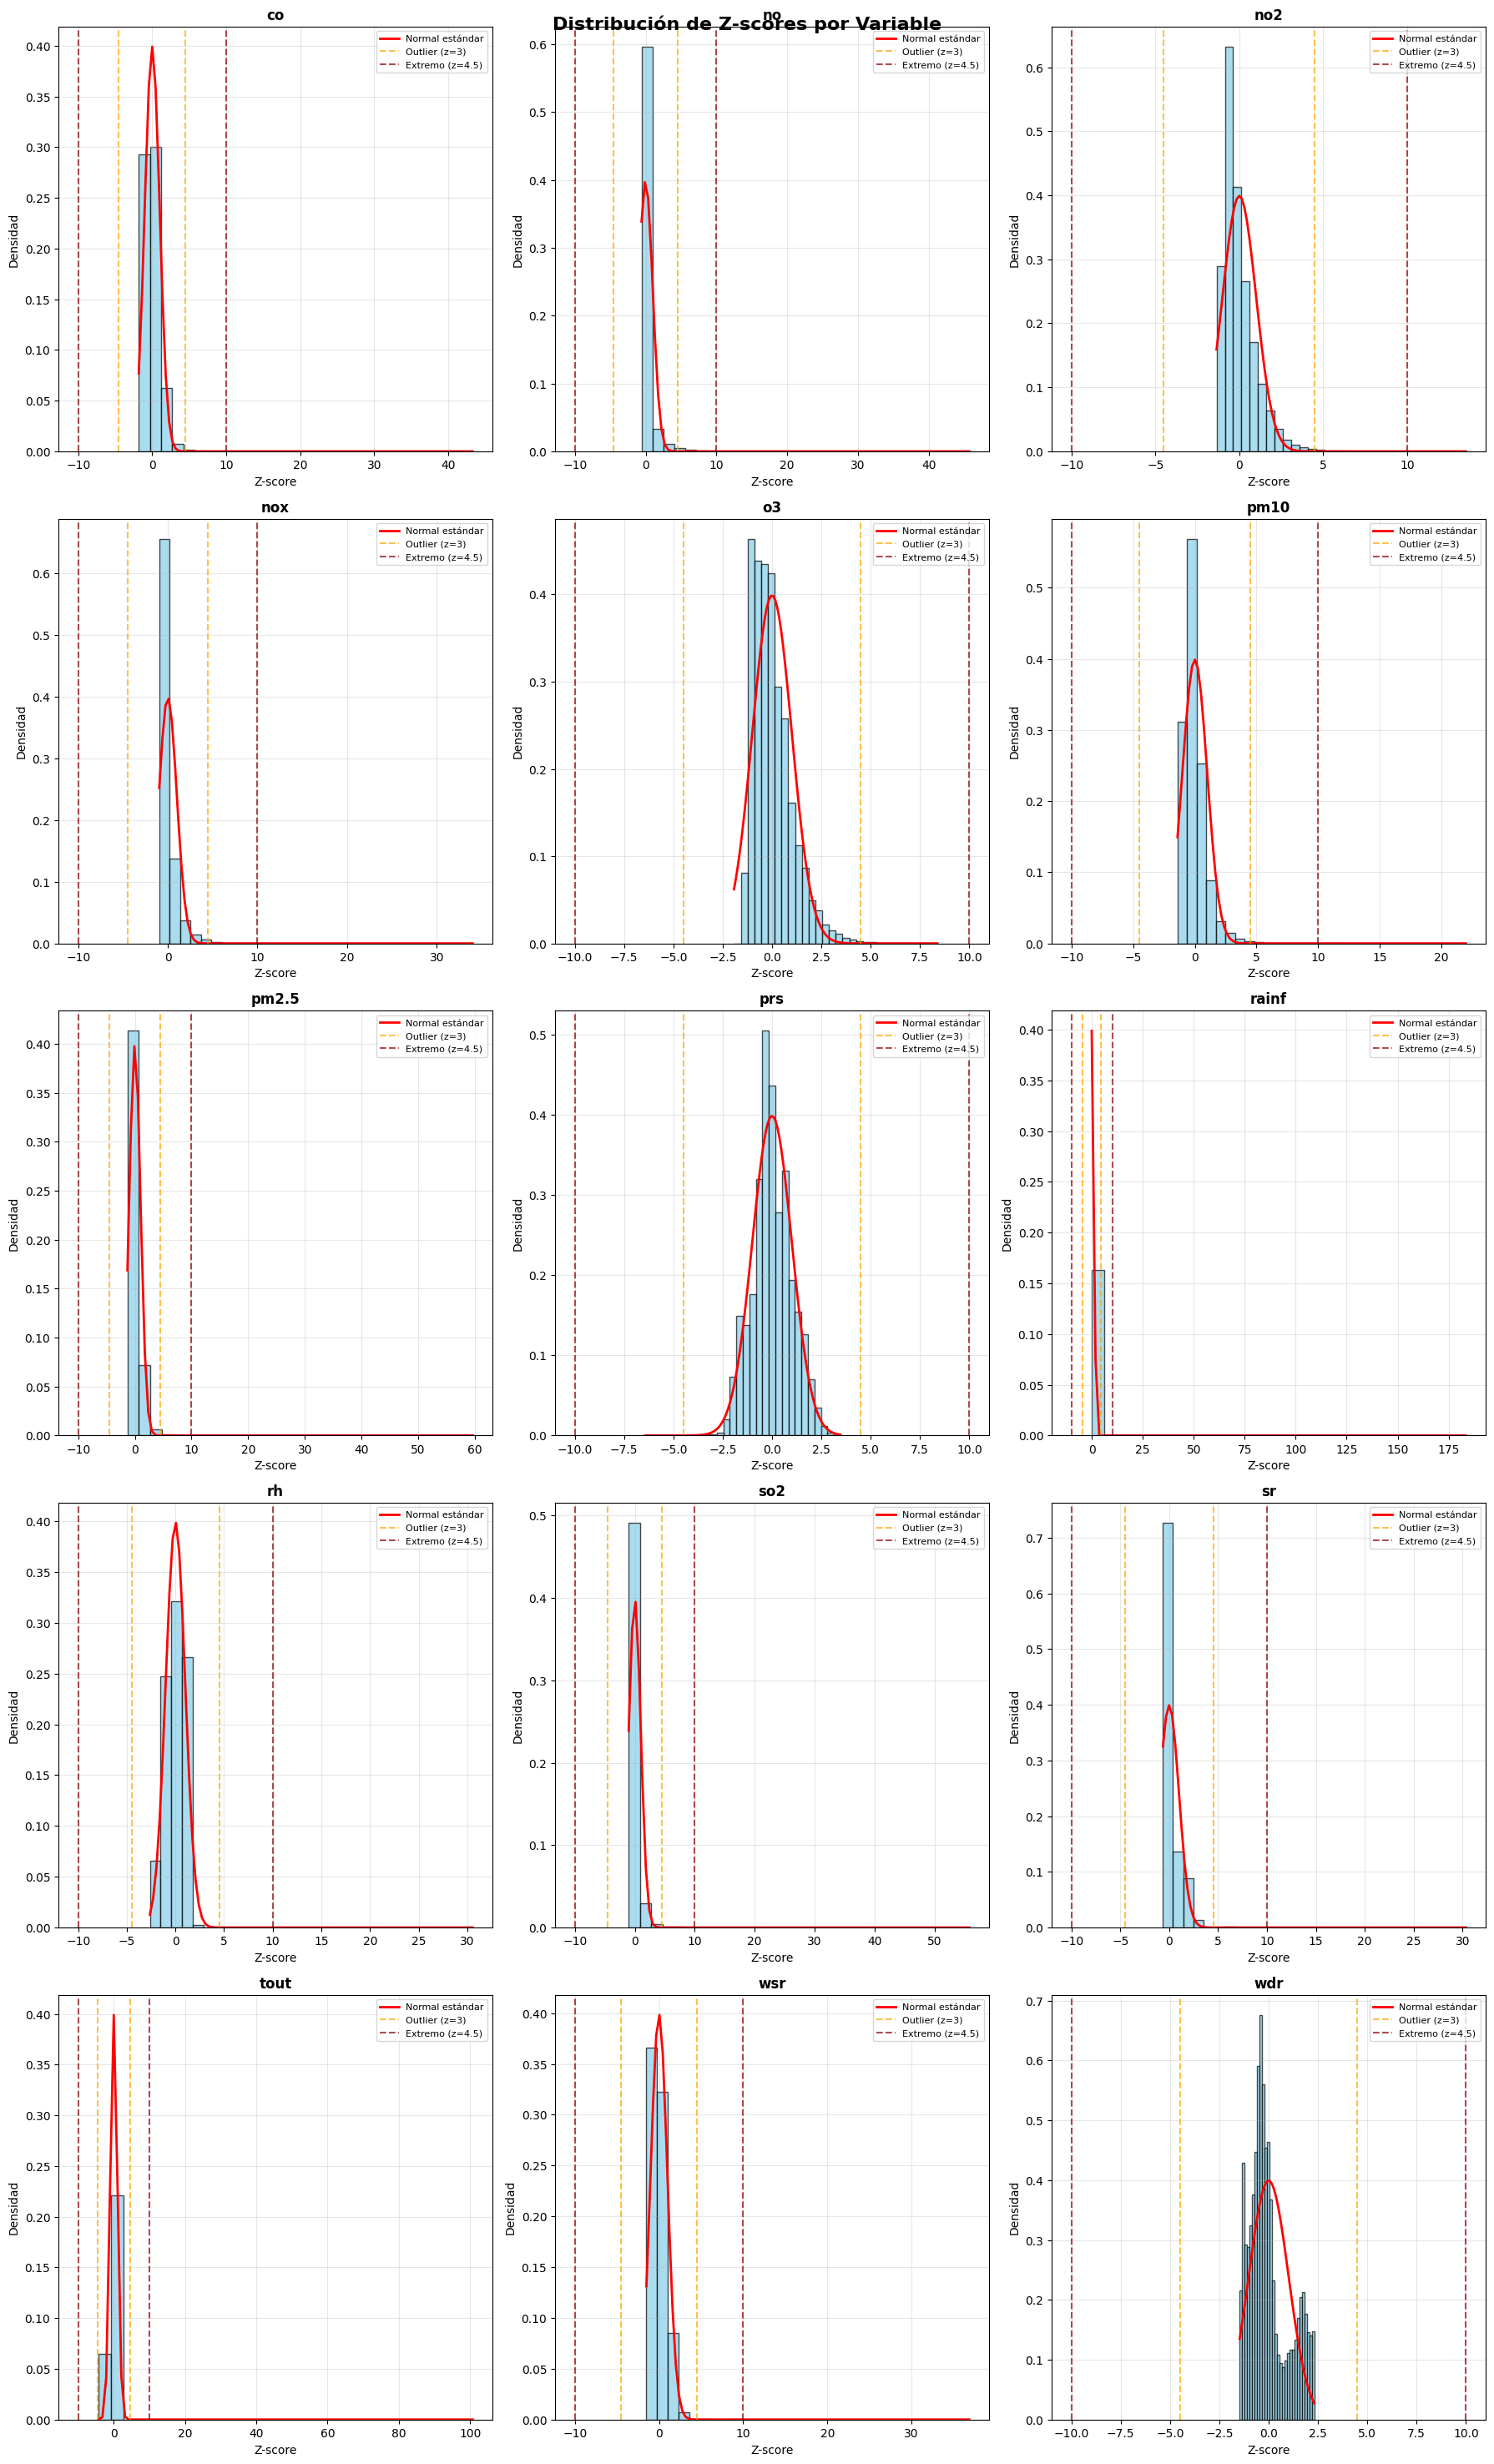

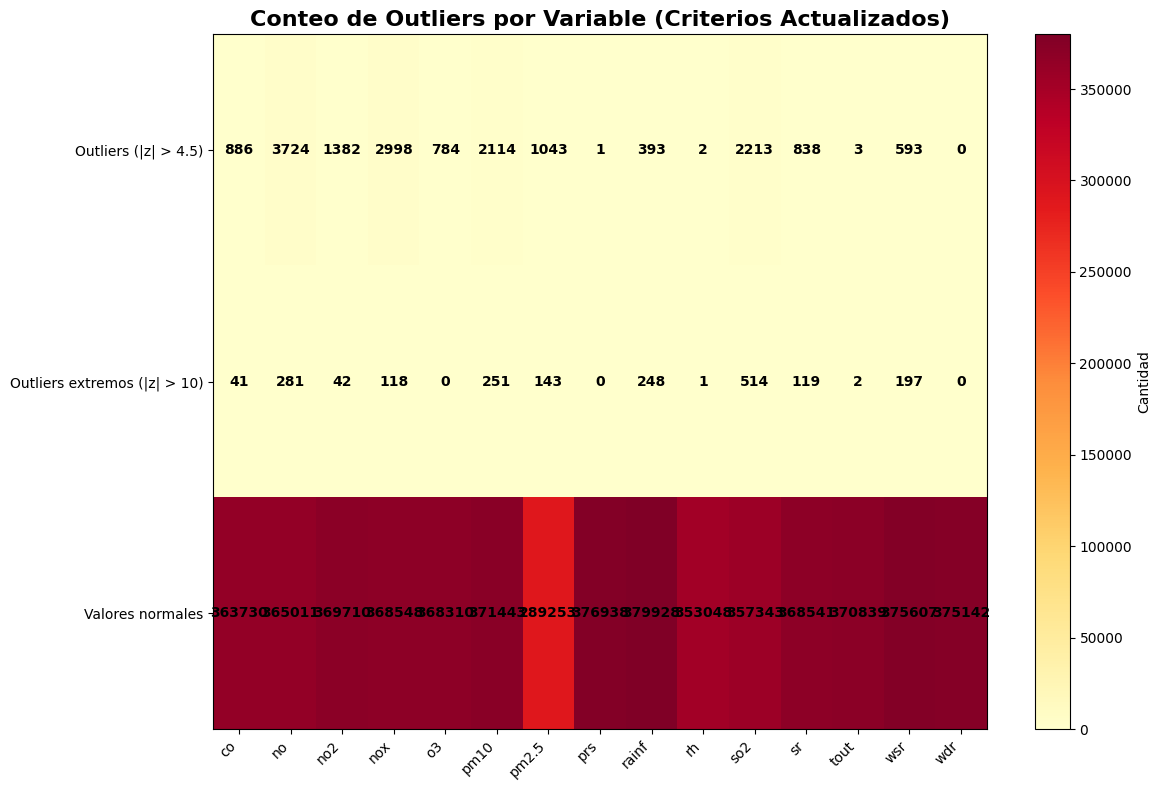


RESUMEN DE ANÁLISIS DE Z-SCORES (CRITERIOS ACTUALIZADOS)

CO:
  • Media: 1.3638
  • Desv. Estándar: 0.8229
  • Rango Z-score: [-1.82, 43.30]
  • Outliers (|z| > 4.5): 886 (0.2%)
  • Outliers extremos (|z| > 10): 41 (0.0%)

NO:
  • Media: 11.9711
  • Desv. Estándar: 20.4146
  • Rango Z-score: [-0.57, 45.71]
  • Outliers (|z| > 4.5): 3724 (1.0%)
  • Outliers extremos (|z| > 10): 281 (0.1%)

NO2:
  • Media: 15.3259
  • Desv. Estándar: 11.2991
  • Rango Z-score: [-1.36, 13.49]
  • Outliers (|z| > 4.5): 1382 (0.4%)
  • Outliers extremos (|z| > 10): 42 (0.0%)

NOX:
  • Media: 27.1126
  • Desv. Estándar: 27.7758
  • Rango Z-score: [-0.96, 34.01]
  • Outliers (|z| > 4.5): 2998 (0.8%)
  • Outliers extremos (|z| > 10): 118 (0.0%)

O3:
  • Media: 26.9284
  • Desv. Estándar: 18.6195
  • Rango Z-score: [-1.93, 8.38]
  • Outliers (|z| > 4.5): 784 (0.2%)
  • Outliers extremos (|z| > 10): 0 (0.0%)

PM10:
  • Media: 60.9569
  • Desv. Estándar: 42.7813
  • Rango Z-score: [-1.40, 21.97]
  • Outliers (|z

In [26]:
# Configuración de estilo para las gráficas
plt.style.use('default')
sns.set_palette("husl")

# Definir las columnas objetivo
target_columns = ['co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2.5', 'prs', 
                 'rainf', 'rh', 'so2', 'sr', 'tout', 'wsr', 'wdr']

def calculate_zscores(df, columns):
    """
    Calcula z-scores para las columnas especificadas
    """
    df_zscores = pd.DataFrame()
    zscore_stats = {}
    
    for col in columns:
        if col in df.columns:
            # Eliminar valores nulos para el cálculo
            clean_data = df[col].dropna()
            
            if len(clean_data) > 0:
                # Calcular z-scores
                z_scores = stats.zscore(clean_data)
                
                # Crear DataFrame con índices originales
                z_series = pd.Series(index=clean_data.index, data=z_scores, name=f'{col}_zscore')
                df_zscores = pd.concat([df_zscores, z_series], axis=1)
                
                # Guardar estadísticas con nuevos criterios
                zscore_stats[col] = {
                    'mean': clean_data.mean(),
                    'std': clean_data.std(),
                    'outliers_count': np.sum(np.abs(z_scores) > 4.5),      # Cambiado a z > 3
                    'extreme_outliers_count': np.sum(np.abs(z_scores) > 10),  # Cambiado a z > 4.5
                    'min_zscore': z_scores.min(),
                    'max_zscore': z_scores.max()
                }
        else:
            print(f"Advertencia: La columna '{col}' no existe en el DataFrame")
    
    return df_zscores, zscore_stats

def plot_boxplots(df, columns):
    """
    Crea boxplots para todas las variables
    """
    # Filtrar columnas que existen
    existing_cols = [col for col in columns if col in df.columns]
    n_cols = len(existing_cols)
    
    if n_cols == 0:
        print("No se encontraron columnas válidas para graficar")
        return
    
    # Calcular número de filas necesarias (4 columnas por fila)
    n_rows = (n_cols + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
    
    # Si solo hay una fila, asegurar que axes sea un array 2D
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols <= 4:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(existing_cols):
        row = i // 4
        col_idx = i % 4
        
        # Obtener datos limpios
        clean_data = df[col].dropna()
        
        if len(clean_data) > 0:
            # Crear boxplot
            box = axes[row, col_idx].boxplot(clean_data, patch_artist=True, 
                                           boxprops=dict(facecolor='lightblue', alpha=0.7),
                                           medianprops=dict(color='red', linewidth=2),
                                           flierprops=dict(marker='o', markerfacecolor='red', 
                                                         markersize=4, alpha=0.5))
            
            # Configurar gráfica
            axes[row, col_idx].set_title(f'{col}', fontsize=12, fontweight='bold')
            axes[row, col_idx].set_ylabel('Valor')
            axes[row, col_idx].grid(True, alpha=0.3)
            
            # Rotar etiquetas del eje x si es necesario
            axes[row, col_idx].tick_params(axis='x', rotation=0)
    
    # Ocultar ejes vacíos
    for i in range(len(existing_cols), n_rows * 4):
        row = i // 4
        col_idx = i % 4
        axes[row, col_idx].set_visible(False)
    
    plt.suptitle('Boxplots de todas las Variables', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_zscore_analysis(df, df_zscores, columns, stats_dict):
    """
    Crea múltiples visualizaciones para el análisis de z-scores
    """
    # Filtrar columnas que existen
    existing_cols = [col for col in columns if col in df.columns]
    n_cols = len(existing_cols)
    
    if n_cols == 0:
        print("No se encontraron columnas válidas para graficar")
        return
    
    # 1. Distribución de Z-scores - Histogramas individuales por variable
    n_cols = len(existing_cols)
    n_rows = (n_cols + 2) // 3  # 3 columnas por fila
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6*n_rows))
    
    # Si solo hay una fila, asegurar que axes sea un array 2D
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols <= 3:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(existing_cols):
        row = i // 3
        col_idx = i % 3
        
        zscore_col = f'{col}_zscore'
        if zscore_col in df_zscores.columns:
            z_data = df_zscores[zscore_col].dropna()
            
            # Crear histograma
            axes[row, col_idx].hist(z_data, bins=30, alpha=0.7, color='skyblue', 
                                  edgecolor='black', density=True)
            
            # Superponer curva normal estándar
            x = np.linspace(z_data.min(), z_data.max(), 100)
            normal_curve = stats.norm.pdf(x, 0, 1)
            axes[row, col_idx].plot(x, normal_curve, 'r-', linewidth=2, 
                                  label='Normal estándar')
            
            # Líneas de referencia para outliers (actualizadas)
            axes[row, col_idx].axvline(x=4.5, color='orange', linestyle='--', alpha=0.7, label='Outlier (z=3)')
            axes[row, col_idx].axvline(x=-4.5, color='orange', linestyle='--', alpha=0.7)
            axes[row, col_idx].axvline(x=10, color='darkred', linestyle='--', alpha=0.7, label='Extremo (z=4.5)')
            axes[row, col_idx].axvline(x=-10, color='darkred', linestyle='--', alpha=0.7)
            
            # Configurar gráfica
            axes[row, col_idx].set_title(f'{col}', fontsize=12, fontweight='bold')
            axes[row, col_idx].set_xlabel('Z-score')
            axes[row, col_idx].set_ylabel('Densidad')
            axes[row, col_idx].grid(True, alpha=0.3)
            axes[row, col_idx].legend(fontsize=8)
    
    # Ocultar ejes vacíos
    for i in range(len(existing_cols), n_rows * 3):
        row = i // 3
        col_idx = i % 3
        axes[row, col_idx].set_visible(False)
    
    plt.suptitle('Distribución de Z-scores por Variable', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. Heatmap de outliers (actualizado)
    if len(existing_cols) > 1:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Crear matriz de outliers con nuevos criterios
        outlier_matrix = np.zeros((len(existing_cols), 3))
        col_names = []
        
        for i, col in enumerate(existing_cols):
            if col in stats_dict:
                outlier_matrix[i, 0] = stats_dict[col]['outliers_count']        # |z| > 3
                outlier_matrix[i, 1] = stats_dict[col]['extreme_outliers_count'] # |z| > 4.5
                outlier_matrix[i, 2] = len(df[col].dropna()) - stats_dict[col]['outliers_count']
                col_names.append(col)
        
        # Crear heatmap
        categories = ['Outliers (|z| > 4.5)', 'Outliers extremos (|z| > 10)', 'Valores normales']
        im = ax.imshow(outlier_matrix.T, cmap='YlOrRd', aspect='auto')
        
        # Configurar ejes
        ax.set_xticks(range(len(col_names)))
        ax.set_xticklabels(col_names, rotation=45, ha='right')
        ax.set_yticks(range(len(categories)))
        ax.set_yticklabels(categories)
        
        # Añadir valores en las celdas
        for i in range(len(categories)):
            for j in range(len(col_names)):
                text = ax.text(j, i, int(outlier_matrix[j, i]), 
                             ha="center", va="center", color="black", fontweight='bold')
        
        ax.set_title('Conteo de Outliers por Variable (Criterios Actualizados)', fontsize=16, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Cantidad')
        plt.tight_layout()
        plt.show()
    
    # 3. Gráficas individuales para variables con más outliers (criterio actualizado)
    high_outlier_vars = []
    for col, stats_info in stats_dict.items():
        outlier_percentage = (stats_info['outliers_count'] / len(df[col].dropna())) * 100
        if outlier_percentage > 2:  # Más del 2% de outliers (ajustado para z > 3)
            high_outlier_vars.append((col, outlier_percentage))
    
    if high_outlier_vars:
        n_vars = len(high_outlier_vars)
        n_rows = (n_vars + 1) // 2
        fig, axes = plt.subplots(n_rows, 2, figsize=(15, 6*n_rows))
        
        # Manejar correctamente los casos de arrays de matplotlib
        if n_vars == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = list(axes)
        else:
            axes = axes.flatten()
        
        for i, (col, pct) in enumerate(high_outlier_vars):
            if i < len(axes):
                zscore_col = f'{col}_zscore'
                if zscore_col in df_zscores.columns:
                    # Scatter plot: valor original vs z-score
                    clean_data = df[col].dropna()
                    z_data = df_zscores[zscore_col].dropna()
                    
                    # Asegurar que los índices coincidan
                    common_idx = clean_data.index.intersection(z_data.index)
                    x_vals = clean_data.loc[common_idx]
                    y_vals = z_data.loc[common_idx]
                    
                    # Colorear según nuevos criterios
                    colors = []
                    for z in y_vals:
                        if abs(z) > 4.5:
                            colors.append('darkred')  # Outliers extremos
                        elif abs(z) > 3:
                            colors.append('red')      # Outliers
                        else:
                            colors.append('blue')     # Normales
                    
                    # Usar el eje correcto
                    current_ax = axes[i] if hasattr(axes[i], 'scatter') else axes[i]
                    current_ax.scatter(x_vals, y_vals, c=colors, alpha=0.6, s=30)
                    current_ax.axhline(y=3, color='orange', linestyle='--', alpha=0.7)
                    current_ax.axhline(y=-3, color='orange', linestyle='--', alpha=0.7)
                    current_ax.axhline(y=4.5, color='darkred', linestyle='--', alpha=0.7)
                    current_ax.axhline(y=-4.5, color='darkred', linestyle='--', alpha=0.7)
                    current_ax.set_xlabel(f'Valor original ({col})')
                    current_ax.set_ylabel('Z-score')
                    current_ax.set_title(f'{col} - {pct:.1f}% outliers')
                    current_ax.grid(True, alpha=0.3)
        
        # Ocultar ejes vacíos
        for i in range(len(high_outlier_vars), len(axes)):
            if hasattr(axes[i], 'set_visible'):
                axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()

def print_zscore_summary(stats_dict):
    """
    Imprime un resumen de las estadísticas de z-scores (criterios actualizados)
    """
    print("\n" + "="*80)
    print("RESUMEN DE ANÁLISIS DE Z-SCORES (CRITERIOS ACTUALIZADOS)")
    print("="*80)
    
    for col, stats_info in stats_dict.items():
        total_points = len(df[col].dropna()) if col in df.columns else 0
        outlier_pct = (stats_info['outliers_count'] / total_points) * 100 if total_points > 0 else 0
        extreme_pct = (stats_info['extreme_outliers_count'] / total_points) * 100 if total_points > 0 else 0
        
        print(f"\n{col.upper()}:")
        print(f"  • Media: {stats_info['mean']:.4f}")
        print(f"  • Desv. Estándar: {stats_info['std']:.4f}")
        print(f"  • Rango Z-score: [{stats_info['min_zscore']:.2f}, {stats_info['max_zscore']:.2f}]")
        print(f"  • Outliers (|z| > 4.5): {stats_info['outliers_count']} ({outlier_pct:.1f}%)")
        print(f"  • Outliers extremos (|z| > 10): {stats_info['extreme_outliers_count']} ({extreme_pct:.1f}%)")

# EJECUCIÓN DEL ANÁLISIS
# ======================

# Calcular z-scores
print("Calculando z-scores...")
df_zscores, zscore_stats = calculate_zscores(df, target_columns)

# Mostrar información básica
print(f"\nZ-scores calculados para {len(df_zscores.columns)} variables")
print(f"Forma del DataFrame de z-scores: {df_zscores.shape}")

# Crear boxplots para todas las variables
print("\nGenerando boxplots...")
plot_boxplots(df, target_columns)

# Crear visualizaciones de z-scores
print("\nGenerando gráficas de z-scores...")
plot_zscore_analysis(df, df_zscores, target_columns, zscore_stats)

# Mostrar resumen estadístico
print_zscore_summary(zscore_stats)

print("\n" + "="*80)
print("ANÁLISIS COMPLETADO")
print("="*80)
print("\nCambios realizados:")
print("• Outliers: |z| > 4.5")
print("• Outliers extremos: |z| > 10")
print("• Se agregaron boxplots para todas las variables")
print("\nEl DataFrame 'df_zscores' contiene los z-scores calculados.")
print("Puedes acceder a los z-scores individuales usando df_zscores['variable_zscore']")